# ARIMA / SARIMA — Walmart Store Sales Forecasting

In [ ]:
try:
    from google.colab import drive
    import os
    drive.mount("/content/drive")
    os.environ["WALMART_ROOT"] = "/content/drive/MyDrive/MLFinalAssignment"
except ImportError:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import importlib.util
import os
import pathlib
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    missing = [p for p in ("lightgbm", "mlflow", "dagshub")
               if importlib.util.find_spec(p) is None]
    if missing:
        print("installing", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    if not pathlib.Path("/content/drive").exists():
        from google.colab import drive
        drive.mount("/content/drive")


def find_root() -> pathlib.Path:
    """Locate the repo: it must hold train.csv and src/walmart_prep.py."""
    candidates = []
    if os.environ.get("WALMART_ROOT"):
        candidates.append(pathlib.Path(os.environ["WALMART_ROOT"]))
    candidates += [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
    if IN_COLAB:
        drive_root = pathlib.Path("/content/drive/MyDrive")
        candidates += [drive_root / "MLFinalProject", pathlib.Path("/content/MLFinalProject")]
        if drive_root.exists():
            candidates += sorted(p for p in drive_root.glob("*") if (p / "train.csv").exists())
    for c in candidates:
        if (c / "train.csv").exists() and (c / "src" / "walmart_prep.py").exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not find the project. Set WALMART_ROOT to the folder containing "
        "train.csv and src/walmart_prep.py, then re-run this cell.\n"
        f"Looked in: {[str(c) for c in candidates]}")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))
for sub in ("docs", "submissions"):
    (ROOT / sub).mkdir(exist_ok=True)

print(f"IN_COLAB={IN_COLAB}\nROOT={ROOT}")

IN_COLAB=True
ROOT=/content/drive/MyDrive/MLFinalAssignment


In [ ]:
import dagshub
import mlflow

dagshub.init(repo_owner='smama23', repo_name='MLFinalProject', mlflow=True)

EXPERIMENT_NAME = 'ARIMA_Training'
REGISTERED_MODEL_NAME = 'WalmartSalesForecast'

mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

print('Tracking URI:', mlflow.get_tracking_uri())
print('Experiment  :', EXPERIMENT_NAME)

Accessing as smama23

Initialized MLflow to track repo "smama23/MLFinalProject"

Repository smama23/MLFinalProject initialized!

Tracking URI: https://dagshub.com/smama23/MLFinalProject.mlflow
Experiment  : ARIMA_Training


In [ ]:
import time

import numpy as np
import pandas as pd

import mlflow
import mlflow.sklearn

import warnings
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from walmart_panel import WalmartPanel, PrecomputedForecaster

from walmart_prep import (
    FOLDS, HORIZON, MARKDOWN_COLS, MIN_SAFE_LAG,
    WalmartFeatureBuilder,
    december_shape_report, load_raw, make_submission,
    score_fold, seasonal_naive, wmae_weights,
)

EXPERIMENT = EXPERIMENT_NAME
print("tracking:", mlflow.get_tracking_uri())

train, test, features, stores = load_raw(str(ROOT))
SEED = 0

print(f"train {train.shape}   test {test.shape}")
print(f"train {train.Date.min().date()} .. {train.Date.max().date()}")
print(f"test  {test.Date.min().date()} .. {test.Date.max().date()}")
print(f"horizon = {HORIZON} weeks  ->  minimum safe lag = {MIN_SAFE_LAG} weeks")

warnings.filterwarnings('ignore')
SEASON = 52

tracking: https://dagshub.com/smama23/MLFinalProject.mlflow
train (421570, 5)   test (115064, 4)
train 2010-02-05 .. 2012-10-26
test  2012-11-02 .. 2013-07-26
horizon = 39 weeks  ->  minimum safe lag = 39 weeks


## Representative series

In [5]:
wk = train.groupby("Date").Weekly_Sales.sum().sort_index()
store1 = train[train.Store == 1].groupby("Date").Weekly_Sales.sum().sort_index()
sd = (train[(train.Store == 1) & (train.Dept == 1)]
      .set_index("Date").Weekly_Sales.sort_index())
SERIES = {"grand_total": wk, "store_1": store1, "store1_dept1": sd}
for name, s in SERIES.items():
    print(f"{name:14s} n={len(s):3d}  mean={s.mean():12.0f}  cycles={len(s)/SEASON:.2f}")

grand_total    n=143  mean=    47113419  cycles=2.75
store_1        n=143  mean=     1555264  cycles=2.75
store1_dept1   n=143  mean=       22513  cycles=2.75


## `ARIMA_Stationarity`

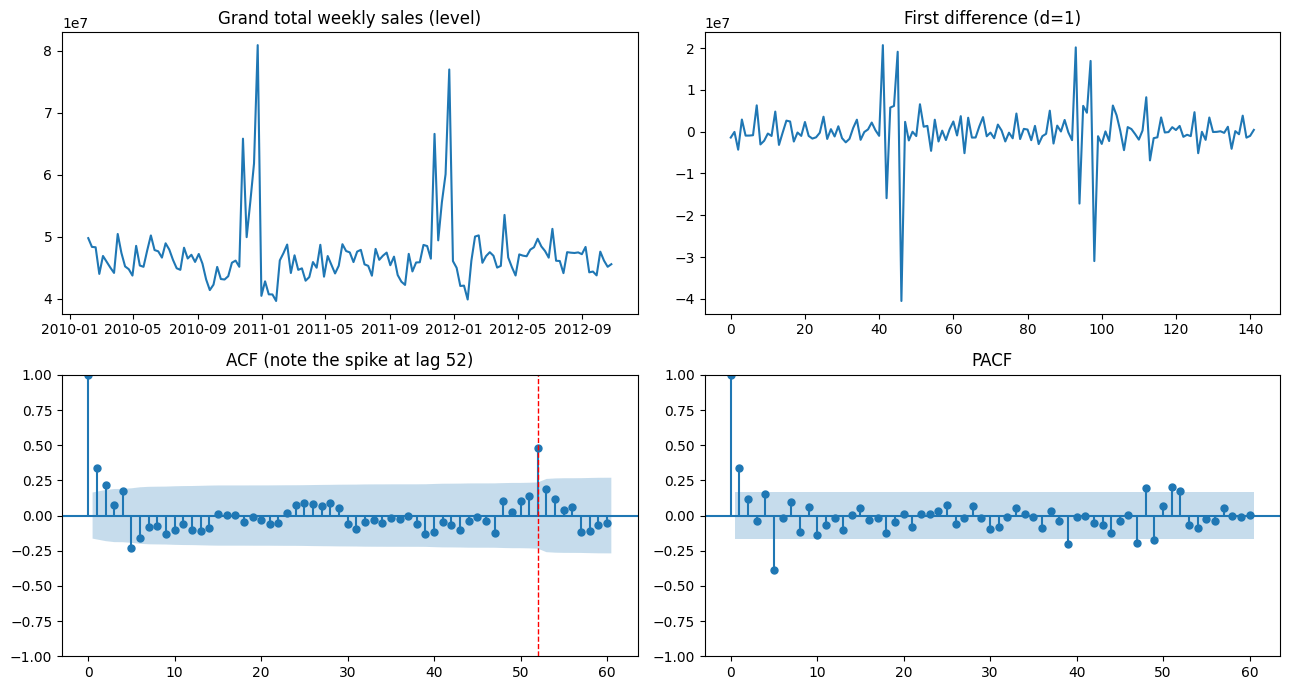

🏃 View run ARIMA_Stationarity at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/f14fececac3f4e79a7000a5ec4908ea0
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3


,series,diff,adf_stat,p_value,stationary_5pct
0,grand_total,level,-5.91,0.0000,True
1,grand_total,d=1,-6.70,0.0000,True
2,store_1,level,-5.10,0.0000,True
3,store_1,d=1,-7.26,0.0000,True
4,store1_dept1,level,-2.52,0.1102,False
5,store1_dept1,d=1,-11.04,0.0000,True


In [ ]:
def adf_row(x):
    x = np.asarray(x, dtype=float)
    stat, p, *_ = adfuller(x, autolag="AIC")
    return {"adf_stat": round(stat, 2), "p_value": round(p, 4),
            "stationary_5pct": p < 0.05}

rows = []
for name, s in SERIES.items():
    rows.append({"series": name, "diff": "level", **adf_row(s)})
    rows.append({"series": name, "diff": "d=1", **adf_row(np.diff(s))})
adf = pd.DataFrame(rows)

with mlflow.start_run(run_name="ARIMA_Stationarity"):
    for _, r in adf.iterrows():
        tag = r["diff"].replace("=", "")
        mlflow.log_metric(f"adf_p_{r.series}_{tag}", r.p_value)

    s = SERIES["grand_total"]
    fig, ax = plt.subplots(2, 2, figsize=(13, 7))
    ax[0, 0].plot(s.index, s.values); ax[0, 0].set_title("Grand total weekly sales (level)")
    ax[0, 1].plot(np.diff(s.values)); ax[0, 1].set_title("First difference (d=1)")
    plot_acf(s.values, ax=ax[1, 0], lags=60); ax[1, 0].axvline(52, color="r", ls="--", lw=1)
    ax[1, 0].set_title("ACF (note the spike at lag 52)")
    plot_pacf(s.values, ax=ax[1, 1], lags=60, method="ywm")
    ax[1, 1].set_title("PACF")
    fig.tight_layout()
    p = ROOT / "docs" / "arima_stationarity.png"; fig.savefig(p, dpi=110); plt.show()
    mlflow.log_artifact(str(p))

adf

## `ARIMA_Baseline`

In [7]:
baseline_scores = {}
with mlflow.start_run(run_name="ARIMA_Baseline"):
    mlflow.log_param("model", "seasonal naive: lag-52, fallback pair median, then global median")
    for fold in FOLDS:
        tr = train[train.Date <= fold.cut]
        va = train[(train.Date >= fold.val_start) & (train.Date <= fold.val_end)]
        s = score_fold(va.Weekly_Sales, seasonal_naive(tr, va), va)
        baseline_scores[fold.name] = s
        mlflow.log_metric(f"wmae_{fold.name}", s["wmae"])

BASELINE = {k: v["wmae"] for k, v in baseline_scores.items()}
pd.DataFrame(baseline_scores).round(1)

🏃 View run ARIMA_Baseline at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/6ece4e23836f4e86a06110b357086e56
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3


,mirror,recent,early
wmae,2037.8,1807.2,2018.6
mae,1949.9,1805.5,1955.9
mae_holiday,2320.2,1815.7,2170.0
mae_nonholiday,1918.6,1804.9,1931.2
bias,-381.1,-375.3,-341.3
mae_thanksgiving,2387.6,NaN,2399.5
mae_christmas,2711.7,NaN,2721.0
mae_superbowl,1860.7,1832.5,1874.9
mae_laborday,NaN,1798.6,1675.8


## `ARIMA_Demo`

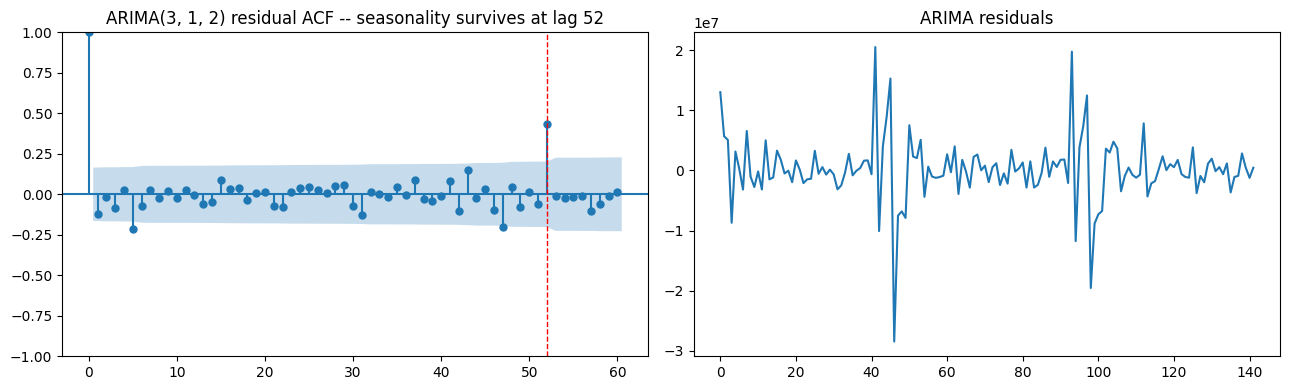

🏃 View run ARIMA_Demo at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/c7d15a1fcb38436e832e1dcca76b8eef
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3
best non-seasonal order by AIC: (3, 1, 2)


,order,aic,bic
5,"(3, 1, 2)",4816.9,4834.6
4,"(2, 1, 2)",4818.4,4833.2
2,"(1, 1, 1)",4820.4,4829.3
3,"(2, 1, 1)",4820.7,4832.6
1,"(0, 1, 1)",4827.1,4833.0
0,"(1, 1, 0)",4832.8,4838.7


In [8]:
s = SERIES["grand_total"].values.astype(float)
grid = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1), (2, 1, 2), (3, 1, 2)]
aic = []
for order in grid:
    try:
        r = ARIMA(s, order=order).fit()
        aic.append({"order": str(order), "aic": round(r.aic, 1), "bic": round(r.bic, 1)})
    except Exception as e:
        aic.append({"order": str(order), "aic": np.nan, "bic": np.nan})
aic = pd.DataFrame(aic).sort_values("aic")
best_order = eval(aic.iloc[0]["order"])

with mlflow.start_run(run_name="ARIMA_Demo"):
    mlflow.log_param("aic_grid", ", ".join(a["order"] for a in aic.to_dict("records")))
    mlflow.log_param("best_order_by_aic", str(best_order))
    res = ARIMA(s, order=best_order).fit()
    mlflow.log_metric("aic_best", res.aic)

    resid = res.resid[1:]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(resid, ax=ax[0], lags=60); ax[0].axvline(52, color="r", ls="--", lw=1)
    ax[0].set_title(f"ARIMA{best_order} residual ACF -- seasonality survives at lag 52")
    ax[1].plot(resid); ax[1].set_title("ARIMA residuals")
    fig.tight_layout()
    p = ROOT / "docs" / "arima_residuals.png"; fig.savefig(p, dpi=110); plt.show()
    mlflow.log_artifact(str(p))

print(f"best non-seasonal order by AIC: {best_order}")
aic

## `SARIMA_Demo`

In [9]:
import time
s = SERIES["grand_total"].values.astype(float)
with mlflow.start_run(run_name="SARIMA_Demo"):
    t0 = time.time()
    sar = SARIMAX(s, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASON),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fit_s = time.time() - t0
    mlflow.log_metric("sarima_fit_seconds", fit_s)
    mlflow.log_metric("sarima_aic", sar.aic)
    mlflow.log_metric("est_full_panel_minutes", fit_s * 3331 / 60)

    ci = sar.conf_int()
    params = pd.DataFrame({"param": sar.param_names, "estimate": sar.params,
                           "ci_low": ci[:, 0], "ci_high": ci[:, 1]})
    params["ci_width"] = params.ci_high - params.ci_low
    print(f"SARIMA(1,1,1)(1,1,1,{SEASON}) fit in {fit_s:.1f}s  AIC={sar.aic:.0f}")
    print(f"extrapolated to 3,331 series: {fit_s*3331/60:.0f} min for one configuration")
    print(f"seasonal cycles available: {len(s)/SEASON:.2f}\n")
    mlflow.log_param("n_seasonal_cycles", round(len(s) / SEASON, 2))
params.round(3)

SARIMA(1,1,1)(1,1,1,52) fit in 6.4s  AIC=1148
extrapolated to 3,331 series: 358 min for one configuration
seasonal cycles available: 2.75

🏃 View run SARIMA_Demo at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/51119a7d21194fe5b734315a326748e7
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3


,param,estimate,ci_low,ci_high,ci_width
0,ar.L1,7.000000e-03,-7.420000e-01,7.550000e-01,1.497
1,ma.L1,-9.170000e-01,-1.292000e+00,-5.430000e-01,0.749
2,ar.S.L52,-2.100000e-02,-2.699800e+01,2.695600e+01,53.954
3,ma.S.L52,-0.000000e+00,-2.700200e+01,2.700100e+01,54.003
4,sigma2,4.006691e+12,4.006691e+12,4.006691e+12,0.000


## `ARIMA_Panel_CV`

In [10]:
def fit_panel_arima(panel, order=(1, 0, 1), verbose_every=1000):
    """Per-series ARIMA on the lag-52 seasonal difference; NaN row -> seasonal-naive fallback."""
    hp = np.full((panel.n_series_, panel.horizon), np.nan)
    fitted = 0
    for i in range(panel.n_series_):
        s = panel.series_history(i)
        if len(s) < SEASON + 8:
            continue
        try:
            d = s[SEASON:] - s[:-SEASON]
            f = ARIMA(d, order=order).fit().forecast(panel.horizon)
            hp[i] = s[-SEASON:-SEASON + panel.horizon] + f
            fitted += 1
        except Exception:
            pass
        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"  fitted {i+1}/{panel.n_series_}")
    return hp, fitted

ORDER = (1, 0, 1)
fold = next(f for f in FOLDS if f.name == "recent")
va = train[(train.Date >= fold.val_start) & (train.Date <= fold.val_end)]
panel = WalmartPanel(train, features, stores, lookback=52).fit(fold.cut)

import time
with mlflow.start_run(run_name="ARIMA_Panel_CV"):
    mlflow.log_params({"order": str(ORDER), "seasonal_diff_lag": SEASON,
                       "method": "seasonal-diff + ARIMA, seasonal-naive fallback",
                       "fold": "recent"})
    t0 = time.time()
    hp, fitted = fit_panel_arima(panel, ORDER)
    fit_min = (time.time() - t0) / 60
    pred = PrecomputedForecaster(panel, hp)(va)
    s = score_fold(va.Weekly_Sales, pred, va)
    mlflow.log_metric("wmae_recent", s["wmae"])
    mlflow.log_metric("series_fitted", fitted)
    mlflow.log_metric("fit_minutes", fit_min)
    print(f"fitted {fitted}/{panel.n_series_} series in {fit_min:.1f} min")
    print(f"ARIMA panel WMAE (recent) = {s['wmae']:.1f}   naive = {BASELINE['recent']:.1f}  "
          f"({100*(1-s['wmae']/BASELINE['recent']):+.1f}%)")
pd.Series(s).round(1)

  fitted 1000/3306
  fitted 2000/3306
  fitted 3000/3306
fitted 3123/3306 series in 5.4 min
ARIMA panel WMAE (recent) = 1791.7   naive = 1807.2  (+0.9%)
🏃 View run ARIMA_Panel_CV at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/28da44e232b142d1a15f8b6133dc7395
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3


,0
wmae,1791.7
mae,1803.5
mae_holiday,1734.5
mae_nonholiday,1807.3
bias,-314.1
mae_superbowl,1606.5
mae_laborday,1864.0


## `ARIMA_Final`

In [11]:
panel_full = WalmartPanel(train, features, stores, lookback=52).fit()
with mlflow.start_run(run_name="ARIMA_Final") as final_run:
    mlflow.log_params({"order": str(ORDER), "seasonal_diff_lag": SEASON, "trained_on": "all 143 weeks"})
    hp_full, fitted = fit_panel_arima(panel_full, ORDER)
    forecaster = PrecomputedForecaster(panel_full, hp_full)
    y_pred = forecaster(test)
    print(f"fitted {fitted}/{panel_full.n_series_} series; predictions n={len(y_pred)} "
          f"mean={y_pred.mean():.0f} finite={np.isfinite(y_pred).all()}")

    from walmart_prep import WalmartFeatureBuilder
    g = (WalmartFeatureBuilder(features, stores)
         .fit(train.drop(columns=["Weekly_Sales"]), train.Weekly_Sales).xmas_profile_)
    frame, verdict = december_shape_report(train, test, y_pred, g)
    print(frame.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
    print(f"\npredicted peak {verdict['peak_predicted']} | implied {verdict['peak_implied']}")
    print("GATE:", "PASS" if verdict["passed"] else "REVIEW -- " + "; ".join(verdict["problems"]))
    mlflow.log_metric("december_xmas_gap_pct", verdict["xmas_gap_pct"])
    mlflow.log_metric("december_gate_passed", int(verdict["passed"]))

    logged_model = mlflow.pyfunc.log_model(
        name="model", python_model=forecaster,
        code_paths=[str(ROOT / "src" / "walmart_prep.py"), str(ROOT / "src" / "walmart_panel.py")],
        input_example=test.head(3))
    MODEL_URI = logged_model.model_uri

    sub = make_submission(test, y_pred, ROOT / "submissions" / "arima.csv")
    mlflow.log_artifact(str(ROOT / "submissions" / "arima.csv"))
    FINAL_RUN_ID = final_run.info.run_id

print(f"\nrun_id = {FINAL_RUN_ID}\nmodel_uri = {MODEL_URI}")
sub.head()

  fitted 1000/3331
  fitted 2000/3331
  fitted 3000/3331
fitted 3175/3331 series; predictions n=115064 mean=16663 finite=True
      week  k_end  predicted  implied  gap_pct
2012-11-30    -25      0.988    0.969    1.966
2012-12-07    -18      1.119    1.109    0.838
2012-12-14    -11      1.221    1.208    1.066
2012-12-21     -4      1.576    1.489    5.805
2012-12-28      3      0.946    1.243  -23.884
2013-01-04     10      0.936    0.919    1.793

predicted peak 2012-12-21 | implied 2012-12-21
GATE: REVIEW -- Christmas week off by -23.9%, beyond the profile's uncertainty


2026/07/11 11:27:00 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 11:27:00 INFO mlflow.pyfunc: Inferring model signature from input example


🏃 View run ARIMA_Final at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3/runs/26efce9d5f624f0bbbc04a6bee77924e
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/3

run_id = 26efce9d5f624f0bbbc04a6bee77924e
model_uri = models:/m-6cce8dc17d874ff2a04df05437fc7c2d


,Id,Weekly_Sales
0,1_1_2012-11-02,36249.608702
1,1_1_2012-11-09,18307.971548
2,1_1_2012-11-16,19002.322469
3,1_1_2012-11-23,20897.028242
4,1_1_2012-11-30,25282.760973


In [ ]:
from mlflow import MlflowClient
loaded = mlflow.pyfunc.load_model(MODEL_URI)
reloaded = np.asarray(loaded.predict(test))
print("max |reloaded - original| =", float(np.abs(reloaded - y_pred).max()))
assert np.allclose(reloaded, y_pred, atol=1e-3), "the logged pyfunc must reproduce its predictions"
print("pyfunc round-trip OK")

mv = mlflow.register_model(MODEL_URI, REGISTERED_MODEL_NAME)
print(f"registered {mv.name} version {mv.version}")
try:
    MlflowClient().set_registered_model_alias(mv.name, "arima", mv.version)
    print(f"alias 'arima' -> version {mv.version}")
except Exception as e:
    print("alias not set (optional):", str(e)[:80])

max |reloaded - original| = 0.0
pyfunc round-trip OK


Registered model 'WalmartSalesForecast' already exists. Creating a new version of this model...
2026/07/11 11:27:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WalmartSalesForecast, version 5
Created version '5' of model 'WalmartSalesForecast'.


registered WalmartSalesForecast version 5
alias 'arima' -> version 5
